Nepal's CPI inflation data (2022-2025)


In [53]:
import pandas as pd
import numpy as np

In [54]:
df = pd.read_excel(
    r'/content/Current-macroeconomic-situation-Tables-Based-on-Six-Month-data-of-2082.83.xlsx',
    sheet_name='5.CPI Y-O-Y',
    skiprows=7,   # skip all title + header rows
    header=None,
    names=['Month',
           'Index_2022', 'Change_2022',
           'Index_2023', 'Change_2023',
           'Index_2024', 'Change_2024',
           'Index_2025', 'Change_2025']
)

# Deleting the Empty Row's
df = df.dropna(subset=['Month'])
df.head()

,Month,Index_2022,Change_2022,Index_2023,Change_2023,Index_2024,Change_2024,Index_2025,Change_2025
0,August,92.224780,8.26,99.1642,7.52,103.222786,4.092061,104.961876,1.684793
1,September,92.376054,8.64,99.9436,8.19,103.804670,3.862563,105.741800,1.866130
2,October,92.945096,8.50,99.9123,7.50,104.728485,4.822822,106.267265,1.469304
3,November,94.538873,8.08,99.6274,5.38,105.202940,5.595852,106.366030,1.105568
4,December,94.147485,7.38,98.8084,4.95,104.790620,6.053816,106.500824,1.632020


Clean the Data::

In [55]:
# drop any NaN rows
df = df.dropna(subset=['Month'])
df = df.reset_index(drop=True)
print(df.shape)

(13, 9)


Concating the Year Values and the convertin it in the list

In [56]:
# combine all 4 change columns directly
all_changes = pd.concat([
    df['Change_2022'],
    df['Change_2023'],
    df['Change_2024'],
    df['Change_2025']
]).dropna().reset_index(drop=True)
values = all_changes.tolist()
print(values)
### Sample Size
sample_size = len(values)
print("Sample Size:", sample_size)

[8.26, 8.64, 8.5, 8.08, 7.38, 7.26, 7.88, 7.44, 7.76, 7.41, 6.83, 7.44, 7.74, 7.52, 8.19, 7.5, 5.38, 4.95, 5.26, 5.01, 4.82, 4.61, 4.4, 4.17, 3.57, 5.44, 4.0920615, 3.8625627, 4.82282170301744, 5.595851604234198, 6.053816401779983, 5.406829190900169, 4.159413908110949, 3.749435102931244, 3.38808360603997, 2.765899558454791, 2.7231434746299215, 2.2049167587984613, 4.06, 1.684792735588431, 1.8661299149643327, 1.4693041725944767, 1.1055679622641748, 1.6320201178311464, 2.419317071252891, 1.6961886624159088]
Sample Size: 46


Calculating the Mean, Standard Deviation and Variance

In [68]:
mean = np.mean(values)
print("Mean:", mean)

Mean: 5.13474252490888


In [71]:
### Variance and Standard Deviation
total = 0
for i in values:
  total += (i-mean)**2
variance = total/(sample_size-1)
print("Variance:", variance)
std = variance ** 0.5
print("Standard Deviation",std)

Variance: 5.141789129081804
Standard Deviation 2.2675513509250025


Calculating the Standard Error

In [72]:
se  = std / (sample_size ** 0.5)
print("Standard Error:", se)

Standard Error: 0.334332206862062


Calculating the Z score, Confident Interval and Margin of the Error

In [88]:
# z score for each value
z_scores = []
for i in values:
    z = (i - mean) / std
    z_scores.append(round(z,4))

print(f"The Z Score of each Values are {(z_scores)}")
print(f"The min Z Score Values is {min(z_scores)}")### It mean 1 standard Deviation below mean
print(f"The max Z Score Values is {max(z_scores)}")##3 It mean 1 Standard Deviation above mean
print(f"The mean of Z score Values is {round(np.mean(z_scores))}")## mean of Z score is always 0

The Z Score of each Values are [np.float64(1.3783), np.float64(1.5458), np.float64(1.4841), np.float64(1.2989), np.float64(0.9902), np.float64(0.9372), np.float64(1.2107), np.float64(1.0166), np.float64(1.1577), np.float64(1.0034), np.float64(0.7476), np.float64(1.0166), np.float64(1.1489), np.float64(1.0519), np.float64(1.3474), np.float64(1.0431), np.float64(0.1082), np.float64(-0.0815), np.float64(0.0552), np.float64(-0.055), np.float64(-0.1388), np.float64(-0.2314), np.float64(-0.324), np.float64(-0.4255), np.float64(-0.6901), np.float64(0.1346), np.float64(-0.4598), np.float64(-0.561), np.float64(-0.1376), np.float64(0.2034), np.float64(0.4053), np.float64(0.12), np.float64(-0.4301), np.float64(-0.6109), np.float64(-0.7703), np.float64(-1.0447), np.float64(-1.0635), np.float64(-1.2921), np.float64(-0.474), np.float64(-1.5214), np.float64(-1.4415), np.float64(-1.6165), np.float64(-1.7769), np.float64(-1.5447), np.float64(-1.1975), np.float64(-1.5164)]
The min Z Score Values is -1.7

In [95]:
### Calculating the Confident Interval
### For the Upper Limit :: 95 % Confident Interval value is 1.96
ci_upp = mean + 1.96*se
ci_low = mean - 1.96*se
print(f"The Upper Limit is {round(ci_upp,4)}")
print(f"The Lower Limit is {round(ci_low,4)}")
print(f"The Confident Interval is {round(ci_low,4)} to {round(ci_upp,4)}")

The Upper Limit is 5.79
The Lower Limit is 4.4795
The Confident Interval is 4.4795 to 5.79


In [97]:
### Calculating the Marign of the Error::
marginal_error = 1.96*se
print(f"The margin of the Error is {round(marginal_error,4)}")

The margin of the Error is 0.6553


Hypothesis Test

In [101]:
# Hypothesis test with assumming mu = 5
mu     = 5.0
### by using the formula::
z_stat = (mean - mu) / se
print(f"\nZ-stat     = {z_stat:.4f}")
print(f"Z-critical = 1.96")

if abs(z_stat) > 1.96:
    print("REJECT H0 ,inflation not equal to  5%")
else:
    print("FAIL TO REJECT H0 , inflation equal to 5%")


Z-stat     = 0.4030
Z-critical = 1.96
FAIL TO REJECT H0 , inflation = 5%


## Conclusion::
The Z-statistic (0.403) is less than the critical value (1.96) at the 95% confidence level, so we fail to reject the null hypothesis. This indicates that Nepal's average CPI inflation is not significantly different from the 5% target, meaning it is consistent with the Nepal Rastra Bank's inflation target.


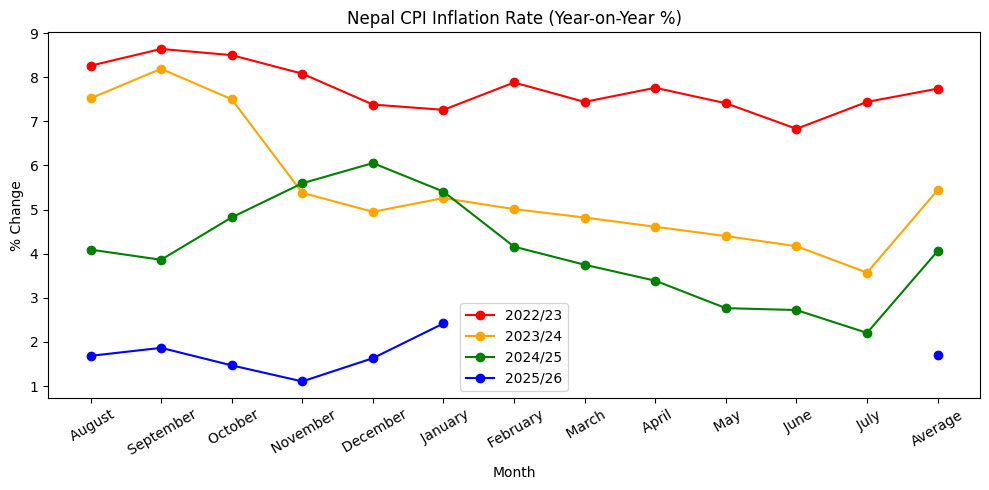

In [109]:
import matplotlib.pyplot as plt

months = df['Month'].tolist()

plt.figure(figsize=(10, 5))
plt.plot(months, df['Change_2022'], marker='o', color='red',   label='2022/23')
plt.plot(months, df['Change_2023'], marker='o', color='orange',label='2023/24')
plt.plot(months, df['Change_2024'], marker='o', color='green', label='2024/25')
plt.plot(months, df['Change_2025'], marker='o', color='blue',  label='2025/26')

plt.title('Nepal CPI Inflation Rate (Year-on-Year %)')
plt.xlabel('Month')
plt.ylabel('% Change')
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()



### Conclusion::
The graph shows Nepal's CPI inflation declining
steadily from 7-8% in 2022/23 to just 1-2% in
2025/26. The average inflation across all years
remains close to 5%, consistent with NRB's target.
This confirms our hypothesis test conclusion that
Nepal's mean inflation is not significantly
different from 5%.